# 02 - Exposure Analysis

This notebook uses the CSV files already generated by notebook 01. It does not create new simulation data.

In [1]:
from pathlib import Path
import os

project_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_dir)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
profile = pd.read_csv('outputs/exposure_profile.csv')
paths = pd.read_csv('outputs/risk_factor_paths.csv')
distributions = pd.read_csv('outputs/exposure_distributions.csv')
netting_sets = pd.read_csv('outputs/netting_set_profile.csv')
netting_summary = pd.read_csv('outputs/netting_set_summary.csv')
trade_summary = pd.read_csv('outputs/trade_summary.csv')

## Simulated market paths

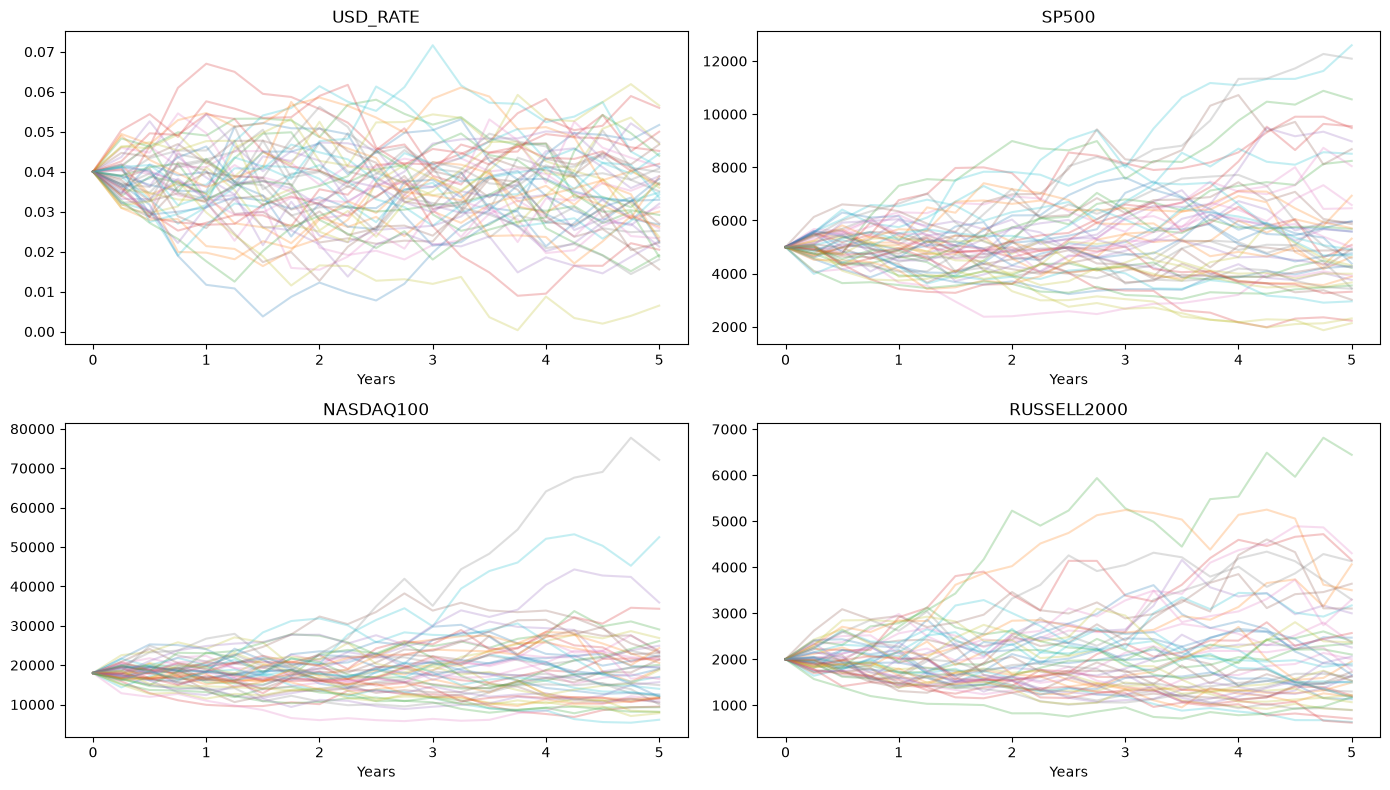

In [4]:
risk_factors = paths['risk_factor'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for chart_number, risk_factor in enumerate(risk_factors):
    data = paths[paths['risk_factor'] == risk_factor]
    for path_number, path in data.groupby('path'):
        axes[chart_number].plot(path['time_years'], path['value'], alpha=0.25)
    axes[chart_number].set_title(risk_factor)
    axes[chart_number].set_xlabel('Years')

plt.tight_layout()
plt.show()

## EE and PFE

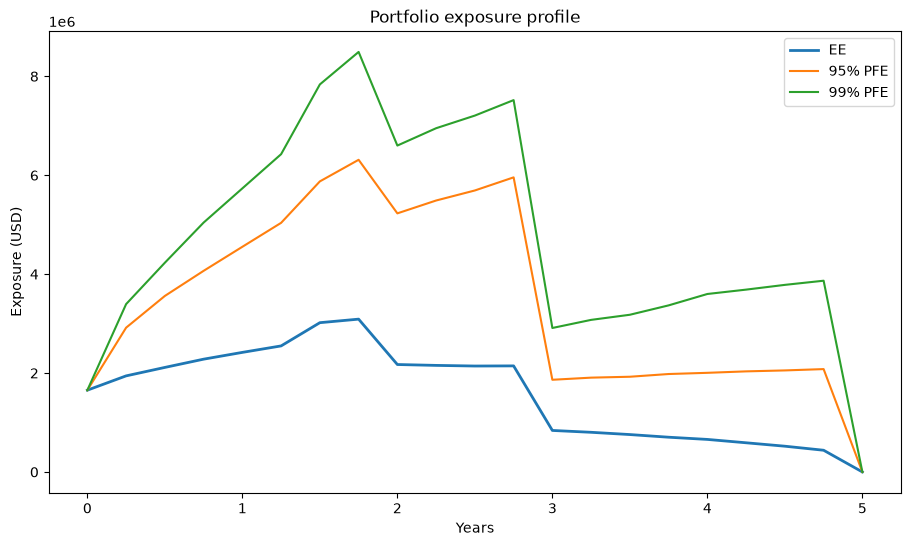

In [5]:
plt.figure(figsize=(11, 6))
plt.plot(profile['time_years'], profile['ee'], label='EE', linewidth=2)
plt.plot(profile['time_years'], profile['pfe_95'], label='95% PFE')
plt.plot(profile['time_years'], profile['pfe_99'], label='99% PFE')
plt.title('Portfolio exposure profile')
plt.xlabel('Years')
plt.ylabel('Exposure (USD)')
plt.legend()
plt.show()

The sharp falls occur when groups of trades mature and their future replacement cost becomes zero.

## Exposure distributions

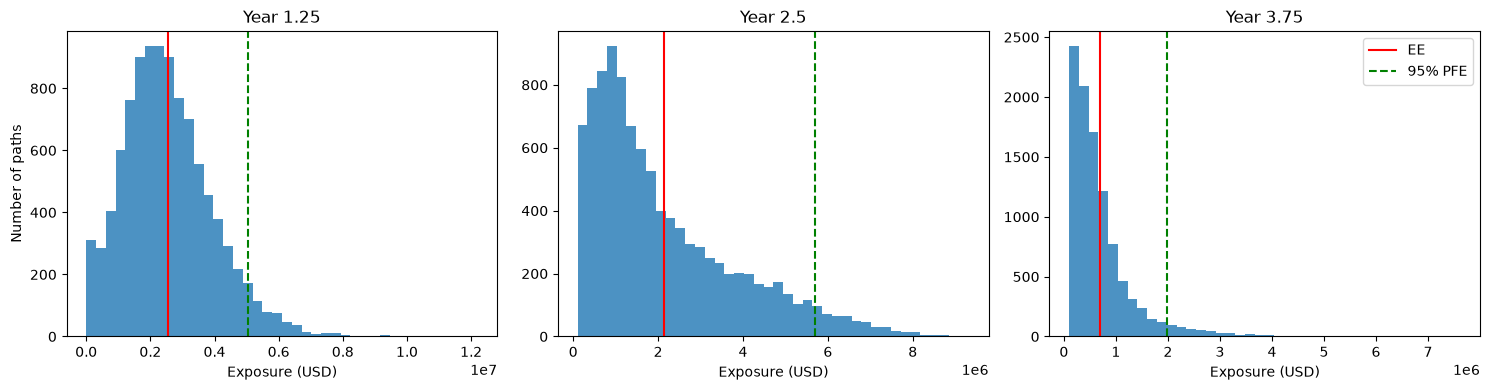

In [6]:
dates = distributions['time_years'].unique()
fig, axes = plt.subplots(1, len(dates), figsize=(15, 4))

for chart_number, time in enumerate(dates):
    values = distributions.loc[distributions['time_years'] == time, 'exposure']
    profile_row = profile.iloc[(profile['time_years'] - time).abs().argmin()]
    axes[chart_number].hist(values, bins=40, alpha=0.8)
    axes[chart_number].axvline(profile_row['ee'], color='red', label='EE')
    axes[chart_number].axvline(profile_row['pfe_95'], color='green', linestyle='--', label='95% PFE')
    axes[chart_number].set_title('Year ' + str(round(time, 2)))
    axes[chart_number].set_xlabel('Exposure (USD)')

axes[0].set_ylabel('Number of paths')
axes[-1].legend()
plt.tight_layout()
plt.show()

PFE is a tail quantile, so it is above EE when the exposure distribution is right-skewed.

## Netting benefit

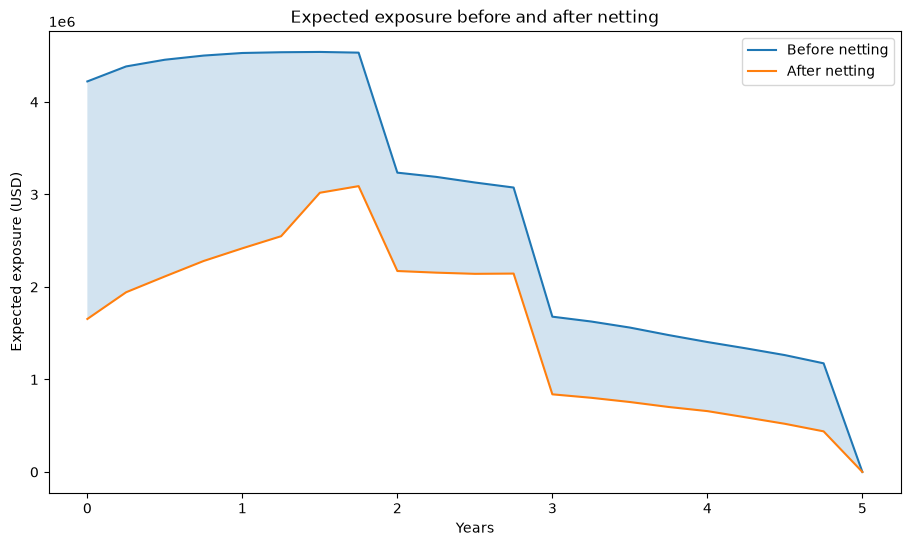

In [7]:
plt.figure(figsize=(11, 6))
plt.plot(profile['time_years'], profile['gross_ee'], label='Before netting')
plt.plot(profile['time_years'], profile['ee'], label='After netting')
plt.fill_between(profile['time_years'], profile['ee'], profile['gross_ee'], alpha=0.2)
plt.title('Expected exposure before and after netting')
plt.xlabel('Years')
plt.ylabel('Expected exposure (USD)')
plt.legend()
plt.show()

## Counterparty and trade analysis

In [8]:
display(netting_summary.sort_values('max_pfe_95', ascending=False))

,netting_set,max_ee,max_pfe_95,max_pfe_99,counterparty
1,NS_BANK_B,2.055903e+06,5.771418e+06,7.361529e+06,Bank B
0,NS_BANK_A,9.334108e+05,4.400973e+06,6.914278e+06,Bank A
2,NS_FUND_C,3.296525e+05,1.973393e+06,3.735994e+06,Fund C


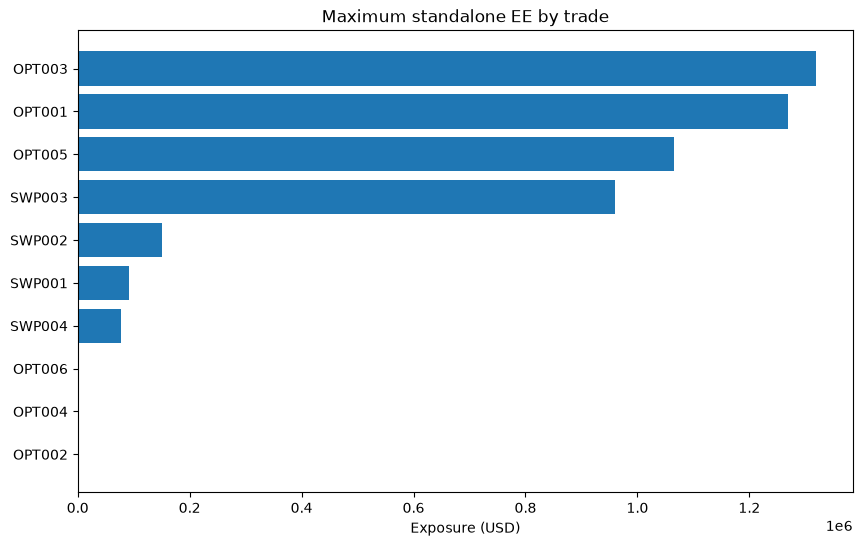

In [9]:
data = trade_summary.sort_values('max_standalone_ee')
plt.figure(figsize=(10, 6))
plt.barh(data['trade_id'], data['max_standalone_ee'])
plt.title('Maximum standalone EE by trade')
plt.xlabel('Exposure (USD)')
plt.show()